In [ ]:
!pip install -U langchain langchain-community langchain-text-splitters langchain-huggingface sentence-transformers chromadb langchain-chroma pymupdf opentelemetry-api opentelemetry-sdk
!pip install langchain-google-genai
# !pip install langchain-groq

## Wstęp

Na poprzednich zajęciach poznaliście sieci neuronowe, dowiedzieliście się jak działają i do czego służą.

W tej lekcji opanujemy podstawy Przetwarzania Języka Naturalnego (NLP). Nauczycie się, jak zamieniać ludzki tekst na postać zrozumiałą dla modeli językowych.

Przejdziemy przez procesy:
- tokenizacji,
- tworzenia osadzeń (embeddingów)
- oraz budowy baz wektorowych.

Przekonacie się też, jak wykorzystać możliwości gotowych modeli, tworząc dzięki nim inteligentnych agentów za pomocą nowoczesnych frameworków.

Wykład jest bezpośrednią kontynuacją uczenia głębokiego, jednak przejdziemy od podstawowych koncepcji do tworzenia kompletnych, nowoczesnych aplikacji z wykorzystaniem technologii RAG (Retrieval-Augmented Generation) oraz mechanizmów pamięci konwersacyjnej.

W notatniku znajdziesz skondensowaną wiedzę pomocną przy budowaniu własnych inteligentnych agentów, zaopatrzoną dodatkowo we fragmenty kodu, które ułatwią wam realizację zadania z kursu Wakacyjnego Wyzwania z wykorzystaniem biblioteki LangChain 🦜🔗 (i LangGraph 🦜🕸️ w celu zapisu poprzednich interakcji z agentem).

W notebooku napotkasz następujące symbole:

- ❓ dodatkowe zagadnienie do samodzielnej realizacji, które pozwoli ci jeszcze bardziej poszerzyć wiedzę,
- 💡 wprowadza ważne, prawdopodobnie nieznane ci narzędzie w Pythonie lub pojęcie, które warto zapamiętać,
- ☝ wskazuje na miejsca potencjalnych błędów czy pomyłek.

---

## **1. Tokenizacja**
### **Tokenizacja – co to jest?**  
🔹 **Proces segmentacji tekstu** – polega na podziale ciągów znaków (zdań, wyrażeń) na mniejsze jednostki zwane **tokenami**.  
🔹 **Podstawa przetwarzania języka** – stosowana w NLP (przetwarzaniu języka naturalnego), analizie tekstu i modelach AI.  
🔹 **Token ≠ słowo** – tokenem może być:  
   • pojedynczy wyraz (np. *"kot"*),  
   • znak interpunkcyjny (np. *","*),  
   • liczba (np. *"42"*),  
   • fragment wyrazu (w językach bez spacji, np. *"深度学习" → "深度", "学习"*).  

### **Dlaczego tokenizacja jest ważna?**  
✅ **Uproszczenie analizy** – komputery lepiej rozumieją małe, ustandaryzowane fragmenty niż całe zdania.  
✅ **Przygotowanie danych** – niezbędny krok przed wektoryzacją (np. dla modeli typu BERT, GPT).  
✅ **Elastyczność** – różne metody tokenizacji (np. BPE, WordPiece) dostosowane do różnych języków i zadań.  

### **Przykłady tokenizacji**  
📌 *"Ala ma kota."* → `["Ala", "ma", "kota", "."]` (tokeny pojedyncze)  
📌 *"I'm happy!"* → `["I", "'", "m", "happy", "!"]` (rozbicie skrótów)  
📌 *"今日は晴れです"* → `["今日", "は", "晴れ", "です"]` (tokeny w japońskim)  

### **Wyzwania w tokenizacji**  
⚠️ **Języki bez spacji** (np. chiński) – wymagają zaawansowanych algorytmów.  
⚠️ **Wieloznaczność** (np. *"3.14"* – liczba czy zdanie z kropką?).  
⚠️ **Skróty i slang** (np. *"działa xd"* → czy *"xd"* to osobny token?).  

Tokenizacja to **kluczowy krok**, który wpływa na skuteczność modeli językowych.

<image src="https://spacy.io/images/tokenization.svg"></image>  

Za pomocą biblioteki SpaCy możemy łatwo przetworzyć tekst za pomocą gotowych tokenizatorów, aby podzielić tekst na tokeny


In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")
doc = nlp("Tekst do podziału na tokeny.")

print([token.text for token in doc])

['Tekst', 'do', 'podziału', 'na', 'tokeny', '.']


W klasycznym NLP musielibyśmy ręcznie załadować tokenizer, stworzyć słownik (vocab) i zamienić tekst na identyfikatory numeryczne:
- 🔢 Mapowanie tokenów na liczby (np. "kot" → 5041)
- 📚 Korzystanie ze słownika tokenów (vocab)

💡 **W naszym zadaniu wykorzystamy do tego LangChain i HuggingFace**
>Nie musimy robić tego ręcznie. Gotowe komponenty (takie jak `HuggingFaceEmbeddings`) automatycznie tokenizują tekst i przekształcają go od razu w **wektory znaczeniowe (embeddingi)**, które trafiają bezpośrednio do naszej bazy wektorowej.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# ścieżka pliku pdf
pdf_path = "/content/drive/MyDrive/Colab Notebooks/ZadanieAgenty/PdfFiles/ksiazka1.pdf"

# ładowanie pliku
loader = PyMuPDFLoader(file_path=pdf_path)
pages = loader.load()

# podział na fragmenty
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=100,
    length_function=len,
    separators=["\n\n", "\n", " ", ""]
)
docs = text_splitter.split_documents(pages)


In [ ]:
print("Liczba załadowanych stron:", len(pages))
print("Liczba utworzonych fragmentów:", len(docs))

Liczba załadowanych stron: 55
Liczba utworzonych fragmentów: 775


Tak prezentują się przykładowe fragmenty wydzielone z pliku:

In [ ]:
for idx,doc in enumerate(docs[75:79]):
  print(f"[{idx}].{doc}\n\n")

[0].page_content='existing behavior.
Maintenance, targeted optimization, and compatibility migration generally sought to preserve defined
scientific behavior, although the permitted implementation changes differed.
For reimplementations,' metadata={'producer': 'pdfTeX-1.40.29', 'creator': 'LaTeX', 'creationdate': '2026-07-27T23:48:41+02:00', 'source': '/content/drive/MyDrive/Colab Notebooks/ZadanieAgenty/PdfFiles/ksiazka1.pdf', 'file_path': '/content/drive/MyDrive/Colab Notebooks/ZadanieAgenty/PdfFiles/ksiazka1.pdf', 'total_pages': 55, 'format': 'PDF 1.7', 'title': 'Scientific computing in the age of agentic AI: an exploratory field report', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-07-27T23:48:41+02:00', 'trapped': '', 'modDate': "D:20260727234841+02'00'", 'creationDate': "D:20260727234841+02'00'", 'page': 4}


[1].page_content='scientific behavior, although the permitted implementation changes differed.
For reimplementations,
workflow consolidations, and hardware-

### 💡 **Tworzenie wektorowej bazy danych z Chroma & Hugging Face Embeddings**  

#### **Co to jest wektorowa baza danych?**  
Wektorowa baza danych (np. **Chroma** w naszym przykładzie) to specjalny rodzaj bazy, która przechowuje dane jako **wektory liczbowe** (tzw. *embeddings*). Każdy fragment tekstu (np. zdanie, akapit) jest zamieniany na ciąg liczb reprezentujących jego znaczenie.  

- **Działa jak wyszukiwarka semantyczna** – znajduje fragmenty podobne znaczeniowo do zapytania (a nie tylko dosłowne dopasowania).  
- **Optymalizuje szybkie wyszukiwanie** – dzięki indeksowaniu wektorów (Chroma to lekka i bardzo popularna baza w ekosystemie LangChain).  

#### 💡 **Jak to działa w naszym kodzie?**  
1. **Generujemy embeddings** (numeryczną reprezentację tekstu):  
   ```python
   embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
   ```  
  - Używamy modelu `sentence-transformers/all-MiniLM-L6-v2` z Hugging Face, który zamienia tekst na kompaktowe wektory **384 liczb**.
  - Jest to niezwykle lekki, ultra szybki i wydajny model, stworzony z myślą o sprawnym wyszukiwaniu semantycznym na słabszym sprzęcie (np. na CPU).
  - Mimo niewielkich rozmiarów doskonale wychwytuje sens zdań.  

2. 💡 **Tworzymy bazę Chroma**:  
   ```python
   vectorstore = Chroma.from_documents(docs, embeddings)
   ```  
   - Dla każdego fragmentu dokumentu (`docs`) obliczamy embedding i zapisujemy go w bazie.  
   - Chroma automatycznie indeksuje wektory w pamięci RAM, aby później szybko wyszukiwać najbliższe znaczeniowo wyniki.  

3. **Mamy także możliwość zapisu bazy na dysku**:  
   ```python
   vectorstore = Chroma.from_documents(
       documents=docs,
       embedding=embeddings,
       persist_directory="./chroma_db"
   )
   ```  
   - Podanie argumentu `persist_directory` powoduje automatyczny zapis bazy w podanym folderze. Możesz ją później wczytać bez ponownego przetwarzania dokumentów.  

#### **Przykład wyszukiwania**  
Gdy zadamy pytanie np. "Jakie są główne wnioski z dokumentu?":  
1. Zapytanie też jest zamieniane na embedding.  
2. Chroma porównuje go z wektorami w bazie i zwraca **najbardziej podobne fragmenty tekstu**.  

#### **Dlaczego to ważne w RAG?**  
- **Retrieval (pobieranie)** – baza wektorowa znajduje fragmenty dokumentu związane z pytaniem.  
- **Generation (generowanie)** – model LLM (np. Gemini czy Zephyr) dostaje te fragmenty jako kontekst i generuje odpowiedź.  

#### **💡 Pamiętajcie:**  
- Im lepszy model embeddingów, tym trafniejsze wyniki wyszukiwania.  
- Możecie testować inne modele z [Hugging Face](https://huggingface.co/models?pipeline_tag=sentence-similarity&sort=trendingl).  

---

W następnym kroku wykorzystujemy tę bazę do **RAG** – model LLM dostaje znalezione fragmenty i generuje odpowiedź!

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
from langchain_chroma import Chroma

vectorstore = Chroma.from_documents(
    documents=docs,
    embedding=embeddings,
    # persist_directory="/content/drive/MyDrive/Colab Notebooks/ZadanieAgenty/"
    )

## Wyszukiwanie podobnych fragmentów przy użyciu retrievera


In [ ]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 3}
    )

In [ ]:
similar = retriever.invoke('What are the opportunities for scientific computing?')
for doc in similar:
  print(doc.page_content[:300] + "...\n---")

goals. Together, these developments create a practical opportunity for scientific computing. Many of the
persistent weaknesses of the scientific computing ecosystem stem from technical debt and a shortage of...
---
goals. Together, these developments create a practical opportunity for scientific computing. Many of the
persistent weaknesses of the scientific computing ecosystem stem from technical debt and a shortage of...
---
scientific computing, ranging from maintenance and packaging to targeted optimization, language-level
reimplementation, and hardware-specific redesign. Across the projects, coding agents provided engineering...
---


Nie jest to idealne rozwiązanie do uzyskiwania podobnych wyszukań, ale jest ono zadowalające i wykorzystywane w wielu systemach, gdzie nie można pozwolić sobie na wtałaczanie ogromnych ilości informacji - czy to przez ograniczenia sprzętowe lub okno kontekstowe modelu.

❓ Możemy również wykorzystywać inne systemy takie jak relacyjne i nierelacyjne bazy danych (SQL, NoSQL) lub grafowe bazy danych (Neo4j)

# ❓ **Transformery**

📌 Czym są transformery?

Nowoczesna architektura sieci neuronowych wprowadzona w 2017 roku w pracy ["Attention Is All You Need"](https://arxiv.org/abs/1706.03762), która zrewolucjonizowała NLP.

![Transformer Architecture](https://d2l.ai/_images/transformer.svg)

🔧 Architektura Encoder-Decoder
- **Encoder** | Analizuje wejściowy tekst | Tłumaczenie: analiza zdania źródłowego
- **Decoder** | Generuje wynik | Tłumaczenie: tworzenie zdania docelowego


🧩 Jak to działa w praktyce?
1. **Tokenizacja** - dzielenie tekstu na części (np. słowa/subwordy)
2. **Embedding** - zamiana na wektory liczbowe
3. **Przetwarzanie** przez warstwy transformerów
4. **Generacja** wyniku

📚 Najpopularniejsze Modele
1. **BERT** - do analizy tekstu
2. **GPT** - do generacji tekstu
3. **T5** - do wielozadaniowości

🌟 Dlaczego warto używać?
- ✔️ Lepsze wyniki niż RNN/LSTM  
- ✔️ Możliwość przetwarzania równoległego  
- ✔️ Bogate pretrenowane modele dostępne od ręki

❓ Więcej na temat transformerów znajdziecie w kursie ["Attention Mechanisms and Transformers"](https://d2l.ai/chapter_attention-mechanisms-and-transformers/index.html)



---

# **2. Duże modele językowe (LLM)**

### Podstawowa charakterystyka

Duże modele językowe (LLM) to zaawansowane systemy AI oparte na architekturze transformerów, zdolne do przetwarzania i generowania tekstu na poziomie zbliżonym do ludzkiego. Ich kluczową cechą jest skalowalność - najnowsze modele mają setki miliardów parametrów i są trenowane na petabajtach danych tekstowych.

### Kluczowe elementy:
- **Transformer architecture**: rdzeń wszystkich współczesnych LLM
- **Skala parametrów**: od kilku milionów do bilionów
- **Zastosowania**: chatboty, generowanie kodu, tłumaczenia, kreatywne pisanie

### Zastosowania i ograniczenia

**Główne zastosowania:**
- Automatyzacja tworzenia treści
- Zaawansowane systemy Q&A
- Personalizowane nauczanie
- Generowanie i debugowanie kodu

**Poważne wyzwania:**
- Ogromne koszty trenowania ($$$ i ślad węglowy)
- Problem "halucynacji" (generowanie nieprawdziwych informacji)
- Wrażliwość na prompt engineering
- Kwestie etyczne (bias, dezinformacja)

## Nowoczesne LLM

>Trening modeli pokroju **GPT-5.6** czy **Gemini 3.1 Pro** od zera wymaga gigantycznych **klastrów GPU** i setek milionów dolarów. Jednak mniejsze wersje otwartych modeli, takich jak **Llama 4** czy **DeepSeek**, posiadając zaawansowane pętle agentowe, multimodalność i obsługę długiego kontekstu, można już z powodzeniem uruchamiać lokalnie na wydajnych urządzeniach.

❓ Jednakże istnieje możliwość korzystania z nich za pomocą płatnych interfejsów API lub hostowania modeli lokalnie np. za pomocą oprogramowania [Ollama](https://ollama.com/)

💡 W naszej pracy skupimy się za to na użyciu darmowego (jednak mocno ograniczonego) API.

# Langchain 🦜🔗

**LangChain** to framework do tworzenia aplikacji wykorzystujących modele językowe (LLM), takie jak GPT. Umożliwia łączenie LLM z zewnętrznymi źródłami danych, narzędziami i pamięcią, co ułatwia budowanie zaawansowanych systemów AI.  

### **Kluczowe funkcje:**  
🔹 **Integracja z modelami** (OpenAI, Hugging Face itp.)  
🔹 **Łańcuchy (Chains)** – łączenie wielu operacji w przepływy  
🔹 **Zarządzanie pamięcią** (np. zapamiętywanie kontekstu w rozmowie)  
🔹 **Praca z danymi** (PDF, bazy danych, internet)  
🔹 **Agenci** – dynamiczne wywoływanie narzędzi w zależności od danych  

### **Zastosowania:**  
- Chatboty z dostępem do własnych danych  
- Automatyzacja zadań z użyciem AI  
- Analiza dokumentów i generowanie treści  

LangChain jest dostępny w językach **Python** i **JavaScript**.  

Jest to bardzo popularna biblioteka do tworzenia nowowczesnych aplikacji z wykrozystaniem LLMów, a także wszelakich modeli NLP lub nawet modeli wizyjnych.

❓Dodatkowo istnieją biblioteki współtowarzyszące procesowi tworzenia aplikacji w LangChain, są to :
- LangGraph 🌐 - biblioteka do tworzenia grafowych sekwencji przepływu programu i sterowanie nim
- LangSmith 🛠️ - biblioteka do monitorowania apliakcji z grupy LangChain, umożliwiając min. podgląd generowanych treści, wydajności systemu czy zgłaszanych błędów produkcyjnych

Podsumowując : 💡 LangChain + LangGraph + LangSmith = Potężny stack do budowy zaawansowanych systemów AI

---

---

# **3. Co dalej?**

Po przygotowaniu pliku i zbudowaniu funkcjonalnego RAG-a, możemy przejść do wykorzystania tak powstałej struktury w praktyce. Stworzymy więc **kompletnego Agenta z narzędziami i pamięcią**. Agent będzie potrafił nie tylko przeszukiwać nasze dokumenty, ale także prowadzić spójną rozmowę, pamiętać poprzednie pytania i bezpiecznie informować o braku danych w bazie.

## **Klucz API**

> Aby w pełni korzystać z możliwości modeli LLM, potrzebujesz klucza dostępu do ich API. Poniżej znajdziesz szybką instrukcję, jak wygenerować **darmowy klucz API** od wybranych dostawców.



---

### Google Gemini
> 1. Przejdź do portalu [Google AI Studio](https://aistudio.google.com/).
2. Zaloguj się za pomocą swojego konta Google.
3. Wybierz opcję **"Get API key"**, kryjącą się pod symbolem klucza 🔑 w menu po lewej.
4. Wybierz **"Create API key"**, później opcja **"Default Gemini Project"** i skopiuj wygenerowany ciąg znaków.

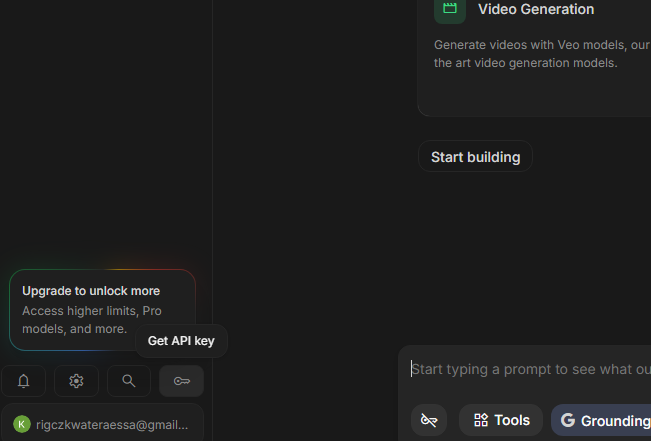



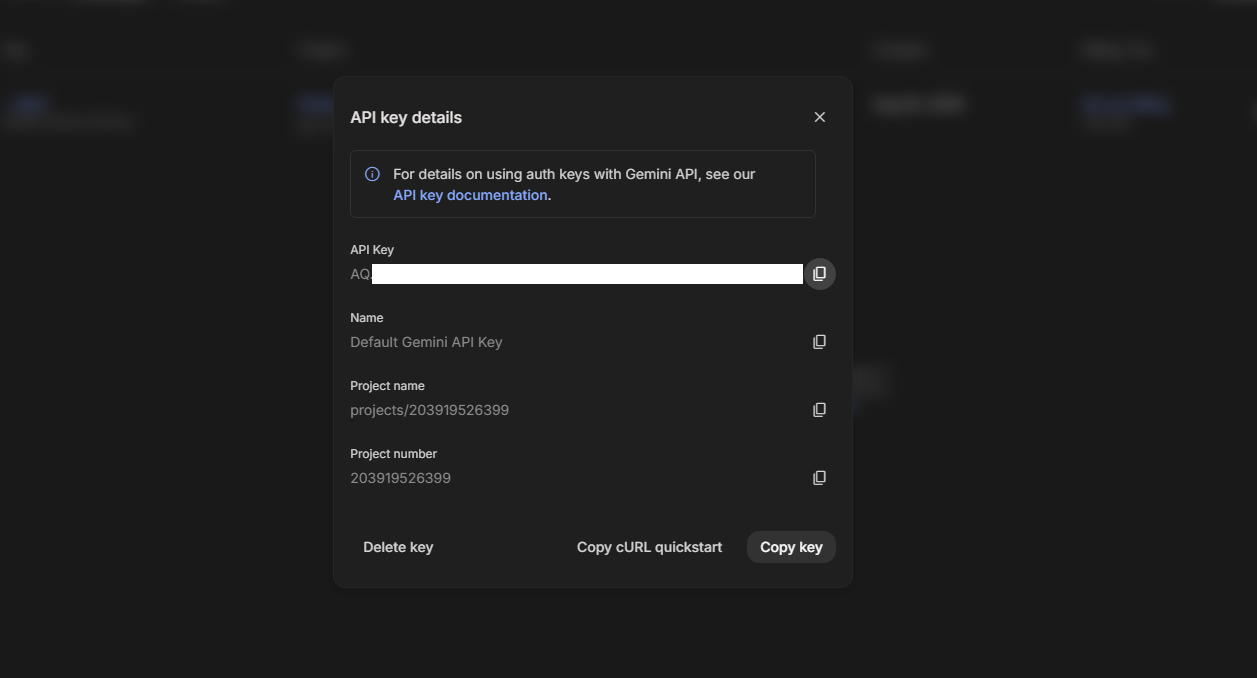

---

### Groq
> 1. Wejdź na platformę [GroqConsole](https://console.groq.com/).
2. Zaloguj się lub utwórz darmowe konto.
3. Przejdź do zakładki **API Keys** z menu na górze strony.
4. Kliknij **"Create API Key"**, nadaj mu nazwę i skopiuj wygenerowany klucz.

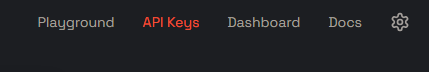



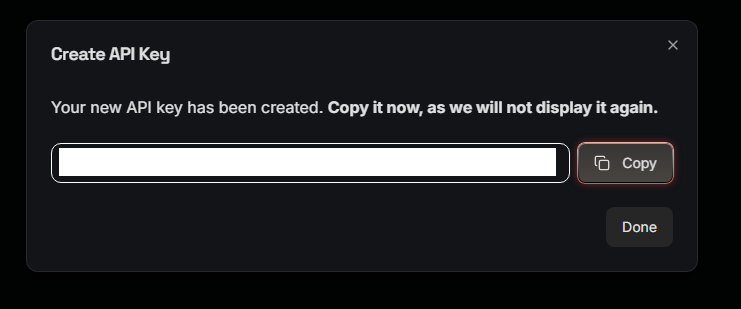

---

> ⚠️ **Ważne:** Nigdy nie udostępniaj swoich kluczy API publicznie! Należy umieścić je w folderze `.env` albo użyć funkcji **secrets** zapewnionej w Colabie (menu po lewej).

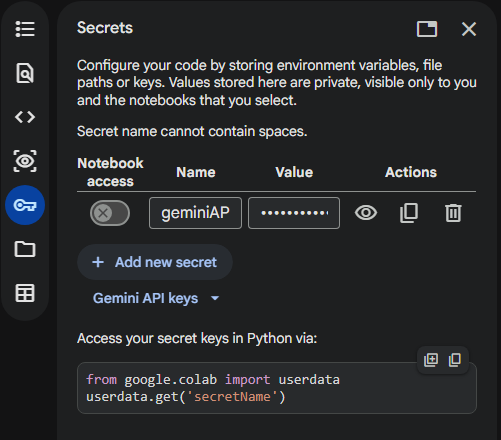

Teraz swój klucz wywołujemy przy pomocy kodu:

In [ ]:
from google.colab import userdata

api_key = userdata.get('geminiAPI')

os.environ["GOOGLE_API_KEY"] = api_key

## Narzędzia dla agenta

Agent sam z siebie nie wie, co znajduje się w Twoich plikach PDF ani jaka jest aktualna godzina. Aby mógł wykonywać zadania, musimy dostarczyć mu **narzędzia**. W frameworku LangChain narzędzie to po prostu funkcja w Pythonie urozmaicona o dekorator `@tool`.

---

### 💡 Po co dekorator `@tool` i czytelny Docstring?

Model językowy nie widzi wewnętrznego kodu funkcji w Pythonie — czyta jedynie jej nazwę, argumenty oraz **docstring** (opis w potrójnych cudzysłowach `"""..."""`).

Opis narzędzia działa jak instrukcja obsługi dla modelu. To na jego podstawie LLM decyduje, **kiedy** uruchomić dane narzędzie i **jakie argumenty** do niego przekazać.

---

### 💡 Definiowanie narzędzi z biblioteką langchain

```python
from langchain_core.tools import tool

@tool
def get_current_weather(location, unit="fahrenheit"):
    """Get the current weather in a given location"""

    print("DEBUG: get_current_weather used")

    weather_info = {
        "location": location,
        "temperature": "72F",
        "unit": unit,
        "forecast": ["sunny", "windy"],
    }
    return weather_info

# Tworzymy listę zawierającą utworzone narzędzie (lub narzędzia)
tools = [get_current_weather]
```

---

☝ **Niejasny docstring:** Jeśli opis funkcji będzie zbyt ogólny (np. `"""Loaded PDF File"""`), model może z niej w ogóle nie skorzystać lub wywoływać ją w złych momentach.

## Przykłady narzędzi:

In [ ]:
from langchain_core.tools import tool
from datetime import datetime

@tool
def get_current_time() -> str:
    """Returns the current date and time.
    Use this tool when the user asks about today, the current time, or the date.
    """
    print("DEBUG: get_current_time used") # w tym notebooku chcemy wiedzieć kiedy wykonywana jest ta funkcja
    # żeby być pewnym, że faktycznie sięgnął po narzędzie i że docstring jest napisany właściwie

    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


@tool
def search_knowledge_base(query: str) -> str:
    """Searches the knowledge base for information from the loaded PDF documents.
    Use this tool when the user asks about the content of the documents.
    """
    print("DEBUG: search_knowledge_base used")

    docs = retriever.invoke(query)

    if not docs:
        return "No matching information in the knowledge base."

    # Wyciągamy samą treść z każdego obiektu w docs i łączymy w jeden tekst
    return "\n\n---\n\n".join([doc.page_content for doc in docs])


tools = [get_current_time, search_knowledge_base]

## Tworzenie agenta

Mając zdefiniowaną listę narzędzi (`tools`), możemy utworzyć **agenta**, czyli model LLM połączony z pętlą decyzyjną (ReAct).

**ReAct Loop** (od słów **Reasoning + Acting**) to wzorzec projektowy i pętla decyzyjna. To właśnie ona zmienia zwykły model językowy w **agenta**.

>Sam model LLM potrafi jedynie generować tekst na podstawie własnej wiedzy. ReAct Loop pozwala mu **myśleć**, **używać zewnętrznych narzędzi** (np. przeszukiwać bazę wiedzy, wykonywać kod, sprawdzać pogodę) i na podstawie wyników tych działań **podejmować kolejne decyzje**.

---

### 💡 Cykl ReAct

Pętla ReAct składa się z trzech powtarzających się kroków:

1. **Thought (Myśl):** Agent analizuje pytanie użytkownika oraz historię dotychczasowych akcji.
2. **Action (Działanie):** Jeśli model uzna, że nie ma wystarczających informacji, wybiera odpowiednie **narzędzie** (tool) i przekazuje do niego argumenty.
3. **Observation (Obserwacja):** Agent odbiera wynik zwrócony przez narzędzie i dołącza go do swojego kontekstu.

>Cykl ten powtarza się tak długo, aż agent zgromadzi wszystkie potrzebne dane. Gdy uzna, że wie wystarczająco dużo, i odpowiada użytkownikowi.

---

### 💡 Jak działa `create_agent` i parametr `system_prompt`?

1. Zgodnie z zasadami pętli ReAct, gdy wywołujesz `agent.invoke()`,  model analizuje pytanie. Jeśli uzna, że potrzebuje danych z zewnątrz:
   * Wysyła żądanie wywołania funkcji (np. `search_knowledge_base`).
   * Otrzymuje wynik z funkcji.
   * Na podstawie otrzymanych danych układa ostateczną odpowiedź dla użytkownika.

2. **Działanie `system_prompt`:**
   >Instrukcja systemowa narzuca agentowi zasadnicze zasady zachowania, osobowość lub format odpowiedzi.

3. W metodzie `agent.invoke()` klucz **`role`** służy do określenia **tożsamości nadawcy** danej wiadomości w historii rozmowy.
> Dzięki temu model nie pomyli surowej treści zwróconej przez narzędzie z pytaniem od użytkownika. Mamy więc listę ról:
'human', 'user', 'ai', 'assistant', 'function', 'tool', 'system', oraz 'developer'.

❓ Role są kluczowe w procesie *LLM as Judge*

In [ ]:
from langchain.agents import create_agent

agent = create_agent(
    model="google_genai:gemini-3.1-flash-lite",
    tools=tools,
    system_prompt="Start each reply with 'Hello world!'."
    )

result1 = agent.invoke({"messages": [{"role": "user", "content": "Search the knowledge base and summarize it in one sentence."}]})
result2 = agent.invoke({"messages": [{"role": "user", "content": "What time is it?"}]})

DEBUG: search_knowledge_base used
DEBUG: get_current_time used


## ☝ Przy wyborze modelu zwróć uwagę na jego wersję

>Darmowe dostępy do API mają swoje limity. W konstrukcjach takich, jak agenci, czasami zapytania mogą być generowane wielokrotnie w przeciągu niecałej minuty. Może to doprowadzić do błędu `429 Rate Limit` i uniemożliwić dalszą pracę. Przez to zamiast nowszego modelu 3.6, w Colabie przy niewymagającym projekcie lepiej z mojego doświadczenia sprawdza się wyżej wspomniany gemini 3.1 flash lite.

In [ ]:
def parse_result(res):
  to_parse = res["messages"][-1]
  return to_parse.content[0]['text']

print(parse_result(result1))
print(parse_result(result2))

Hello world! The documents discuss the challenges of ensuring convergence for statistical summaries in HMC/NUTS and HART extensions, alongside an analysis of the high disk I/O requirements of various quality control tools.
Hello world! The current time is 12:28 AM on August 21, 2026.


## Zapis stanu i pamięć konwersacji (Checkpointer)

Domyślnie każde wywołanie `agent.invoke()` traktowane jest jako osobna, niezależna rozmowa. Aby agent potrafił **pamiętać kontekst poprzednich pytań**, musimy wyposażyć go w mechanizm zapisu stanu (tzw. *checkpointer*).

---

### 💡 Jak działa `InMemorySaver` i `thread_id`?

1. **`InMemorySaver()`**:
   To wbudowany moduł pamięci operacyjnej (RAM). Po każdym kroku agenta automatycznie zapisuje aktualny stan konwersacji na liście wiadomości.

2. **`thread_id` (Identyfikator wątku)**:
   Przekazywany w obiekcie `RunnableConfig`. Stanowi unikalne ID czatu — wskazuje agentowi, z którą konkretną historią rozmowy ma powiązać nowe pytanie. Daje to możliwość prowadzenia równoległych rozmów z wieloma użytkownikami bez miesz`ania ich kontekstów.

---

☝ **InMemorySaver to pamięć krótkotrwała:** przechowuje historię tylko w pamięci operacyjnej programu. Po zrestartowaniu skryptu cała historia zniknie.


❓ (Do trwałego zapisu w bazach produkcyjnych stosuje się np. `SqliteSaver` lub `PostgresSaver`).

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig

agent = create_agent(
    model="google_genai:gemini-3.1-flash-lite",
    tools=tools,
    system_prompt="Start each reply with 'AI Szpont:', speak in a Gen Z way.",
    checkpointer=InMemorySaver()
    )

config: RunnableConfig = {"configurable": {"thread_id": "1"}}

def run_agent(query: str, config: RunnableConfig):
  result = agent.invoke({"messages": [{"role": "user", "content": query}]}, config)
  return parse_result(result)

result_list = list()

result_list.append(run_agent("What time is it now?", config))
result_list.append(run_agent("What day of the week is today?", config))
result_list.append(run_agent("What did I ask you in the beginning?", config))

for res in result_list:
  print(res)

DEBUG: get_current_time used
AI Szpont: It’s currently 12:30 AM, bestie. Don't ask me why we're up this late—we're just thriving. 💅✨
AI Szpont: Today is Friday, bestie! We made it to the weekend—or at least, the very beginning of it. Time to celebrate or just rot in bed, honestly. 💅✨
AI Szpont: You asked me what time it is, bestie! Keeping the receipts on your questions, no worries. 💅✨


Tak utworzony agent AI z pamięcią jest kompletnym i funkcjonalnym narzędziem, które mogłoby zostać zaaplikowane w bardziej rozbudowanym programie.

# Podsumowanie

>W tym module zapoznaliście się z procesami i narzędziami NLP - od tokenizacji i transformerów do LangChain'owych agentów. Wiedzę z tego notebooka przetrenujecie w praktyce wykonując zadanie.

Polecam zainteresować się także dodatkowymi materiałami i treściami dla chętnych, których zaaplikowanie w swojej pracy poszerzy wasze zrozumienie tematu.

W razie pytań - z chęcią pomożemy.

🔗 Przydatne linki:

- [Dokumentacja LangChain](https://docs.langchain.com/oss/python/langchain/agents)

- [Google AI Studio](https://aistudio.google.com/)

- [GroqConsole](https://console.groq.com/)